# Análisis de Secretos — Gitleaks

Análisis de los hallazgos de **Gitleaks** sobre el historial Git de cada repositorio.  
El objetivo es clasificar los secretos detectados por **tipo de regla**, **archivo**, **entropía** y **patrón temporal** para entender qué categorías de credenciales/tokens están expuestas y en qué contextos.

**Archivo fuente:** `{repo}-gitleaks.json`  
**Campos clave:** `RuleID`, `Description`, `File`, `Entropy`, `Author`, `Date`, `Tags`

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_DIR    = Path('../../data/results')
GITLEAKS_FILES = sorted(RESULTS_DIR.glob('*-gitleaks.json'))

assert GITLEAKS_FILES, 'No se encontraron archivos Gitleaks. Ejecuta el pipeline primero.'
print(f'Archivos Gitleaks encontrados: {len(GITLEAKS_FILES)}')
for f in GITLEAKS_FILES:
    print(' -', f.name)

Archivos Gitleaks encontrados: 9
 - Requests-gitleaks.json
 - WordPress-Coding-Standards-gitleaks.json
 - WordPress-gitleaks.json
 - agent-skills-gitleaks.json
 - gutenberg-examples-gitleaks.json
 - gutenberg-gitleaks.json
 - mcp-adapter-gitleaks.json
 - two-factor-gitleaks.json
 - wordpress-develop-gitleaks.json


## 1. Carga y normalización de hallazgos

In [2]:
registros = []
for gl_file in GITLEAKS_FILES:
    repo = gl_file.name.replace('-gitleaks.json', '')
    data = json.loads(gl_file.read_text(encoding='utf-8'))

    hallazgos = []
    if isinstance(data, list):
        hallazgos = data
    elif isinstance(data, dict):
        hallazgos = data.get('hallazgos', data.get('findings', data.get('leaks', [])))

    for h in hallazgos:
        archivo = h.get('File', '')
        ext = Path(archivo).suffix.lower() if archivo else 'sin extensión'
        registros.append({
            'repositorio':   repo,
            'rule_id':       h.get('RuleID', 'desconocida'),
            'descripcion':   h.get('Description', ''),
            'archivo':       archivo,
            'extension':     ext if ext else 'sin extensión',
            'linea_inicio':  h.get('StartLine', None),
            'entropia':      h.get('Entropy', 0.0),
            'autor':         h.get('Author', ''),
            'email':         h.get('Email', ''),
            'fecha':         h.get('Date', ''),
            'commit':        h.get('Commit', '')[:8] if h.get('Commit') else '',
            'tags':          ', '.join(h.get('Tags', [])) if h.get('Tags') else 'sin tags',
        })

df = pd.DataFrame(registros)
if not df.empty:
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce', utc=True)

print(f'Total de hallazgos: {len(df)}')
print(f'Repositorios con hallazgos: {df["repositorio"].nunique() if not df.empty else 0}')
df.head()

Total de hallazgos: 291
Repositorios con hallazgos: 5


,repositorio,rule_id,descripcion,archivo,extension,linea_inicio,entropia,autor,email,fecha,commit,tags
0,WordPress,generic-api-key,"Detected a Generic API Key, potentially exposi...",wp-includes/js/dist/editor.min.js,.js,12,3.572431,John Blackbourn,johnbillion@git.wordpress.org,2026-03-04 12:18:38+00:00,689efdf0,sin tags
1,WordPress,linkedin-client-secret,"Discovered a LinkedIn Client secret, potential...",wp-content/themes/twentytwentyfive/patterns/pa...,.php,48,2.827820,desrosj,desrosj@git.wordpress.org,2024-10-07 18:09:21+00:00,8410b2fc,sin tags
2,WordPress,generic-api-key,"Detected a Generic API Key, potentially exposi...",wp-includes/js/dist/editor.min.js,.js,12,3.572431,audrasjb,audrasjb@git.wordpress.org,2024-06-24 15:20:47+00:00,c494c57e,sin tags
3,WordPress,generic-api-key,"Detected a Generic API Key, potentially exposi...",wp-includes/js/dist/editor.min.js,.js,19,3.572431,audrasjb,audrasjb@git.wordpress.org,2024-06-24 15:18:23+00:00,0d21ceb6,sin tags
4,WordPress,generic-api-key,"Detected a Generic API Key, potentially exposi...",wp-includes/js/dist/editor.min.js,.js,7,3.572431,ellatrix,ellatrix@git.wordpress.org,2024-05-23 19:39:28+00:00,1fbf5fa5,sin tags


## 2. Tipos de secretos detectados (RuleID)

Tipos de reglas distintas: 5
rule_id
generic-api-key           263
curl-auth-user             11
linkedin-client-id          9
curl-auth-header            6
linkedin-client-secret      2


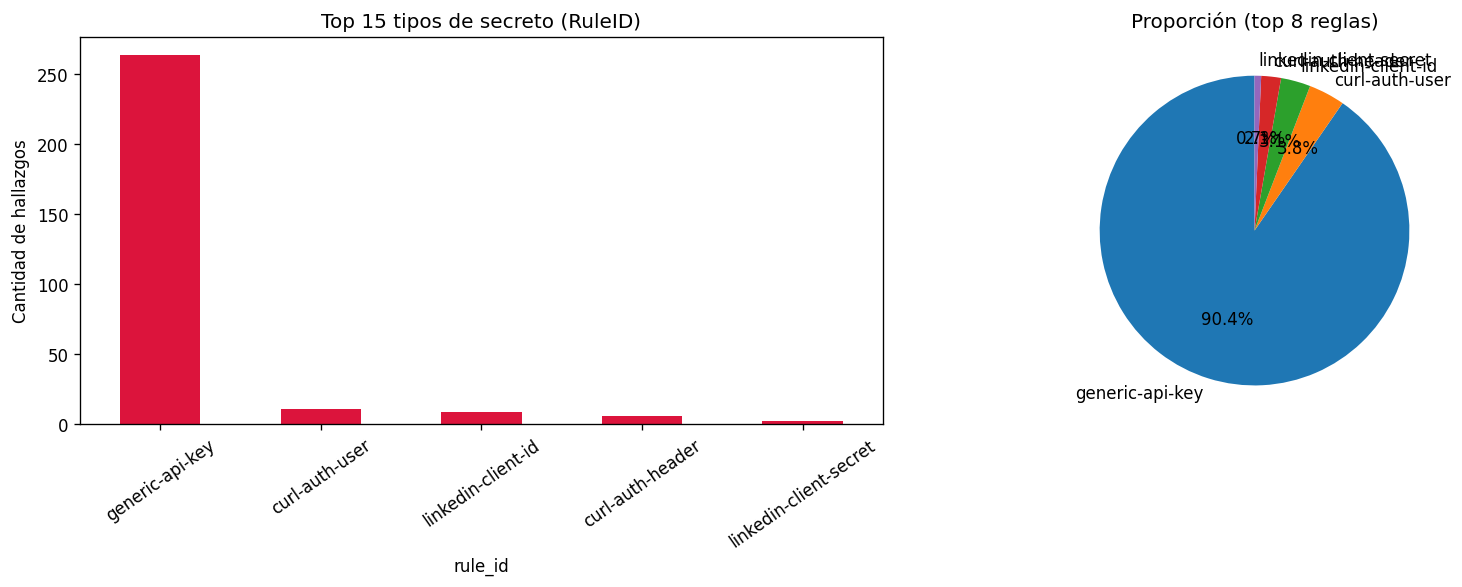

In [3]:
if df.empty:
    print('Sin hallazgos.')
else:
    rule_counts = df['rule_id'].value_counts()
    print(f'Tipos de reglas distintas: {len(rule_counts)}')
    print(rule_counts.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    rule_counts.head(15).plot(kind='bar', ax=axes[0], color='crimson')
    axes[0].set_title('Top 15 tipos de secreto (RuleID)')
    axes[0].set_ylabel('Cantidad de hallazgos')
    axes[0].tick_params(axis='x', rotation=35)

    top_pie = rule_counts.head(8)
    axes[1].pie(top_pie, labels=top_pie.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Proporción (top 8 reglas)')

    plt.tight_layout()
    plt.show()

## 3. Categorías de secretos por repositorio

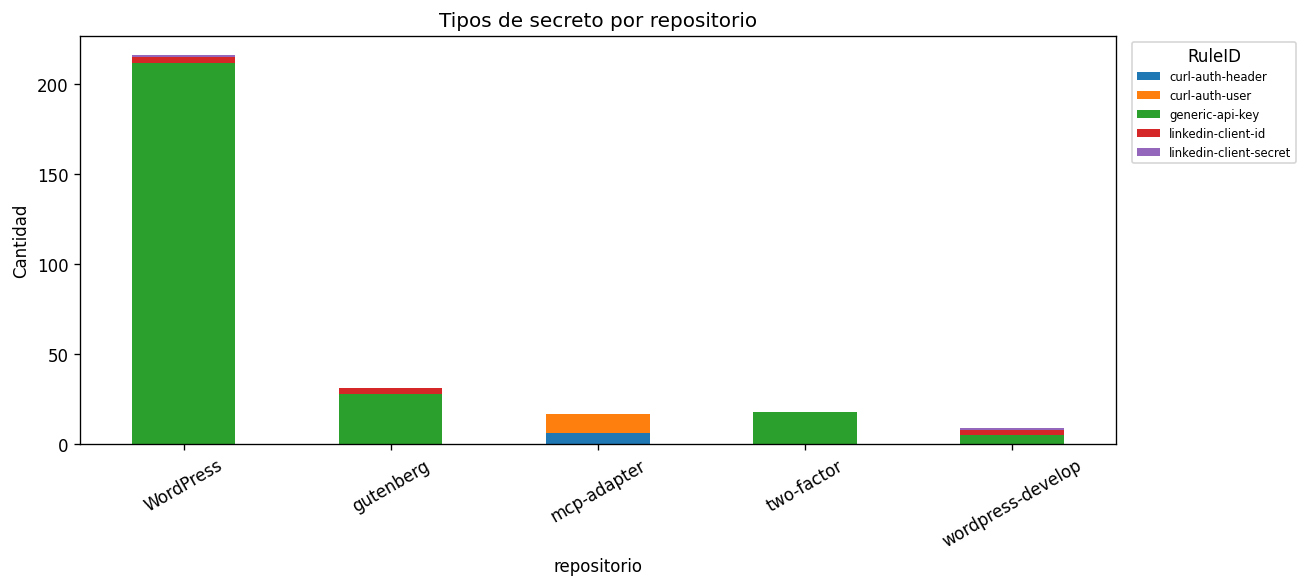

In [4]:
if not df.empty:
    pivot = df.pivot_table(
        index='repositorio', columns='rule_id',
        values='archivo', aggfunc='count', fill_value=0
    )
    pivot.plot(kind='bar', stacked=True, figsize=(11, 5))
    plt.title('Tipos de secreto por repositorio')
    plt.ylabel('Cantidad')
    plt.legend(title='RuleID', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
    plt.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 4. Tipos de archivo afectados

Extensiones de archivo con más hallazgos:
extension
.js      225
.php      38
.md       17
.tsx       9
.snap      2


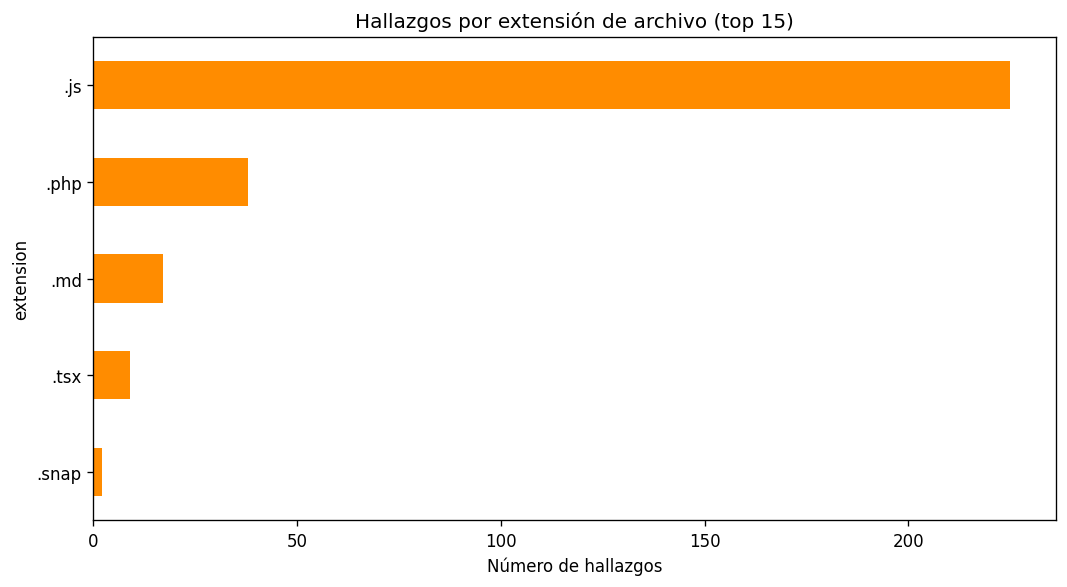

In [5]:
if not df.empty:
    ext_counts = df['extension'].value_counts().head(15)
    print('Extensiones de archivo con más hallazgos:')
    print(ext_counts.to_string())

    ext_counts.plot(kind='barh', figsize=(9, 5), color='darkorange')
    plt.title('Hallazgos por extensión de archivo (top 15)')
    plt.xlabel('Número de hallazgos')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Análisis de entropía por tipo de regla

/tmp/ipykernel_595977/4050593970.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grupos, labels=top_rules, patch_artist=True, notch=False)


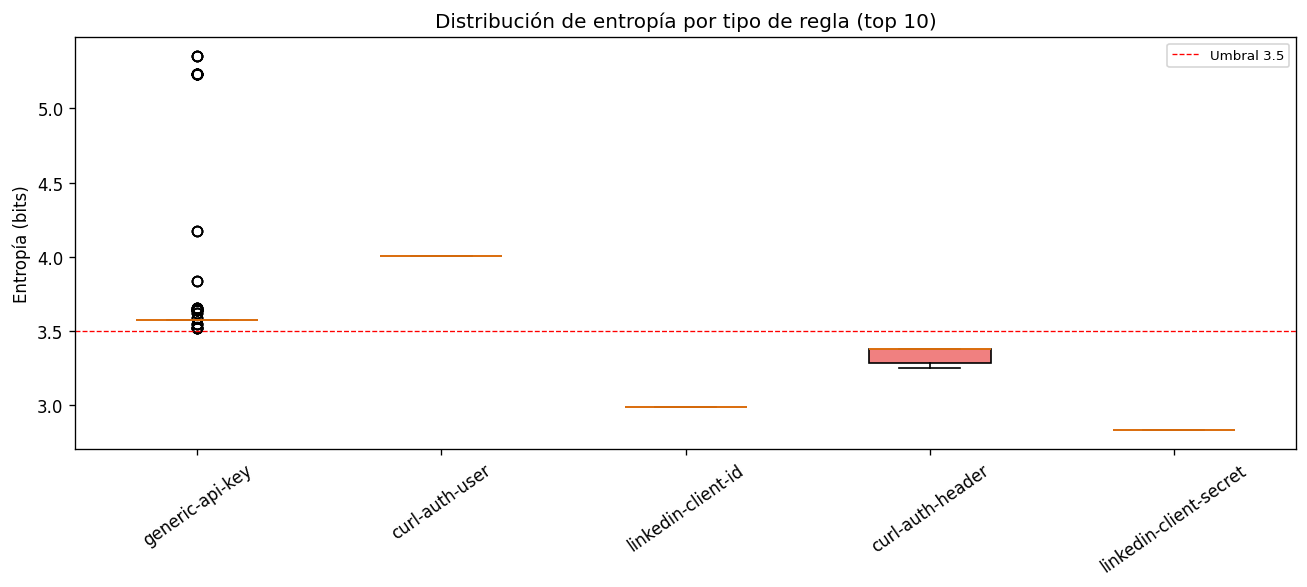

                        count   mean    std    min    25%    50%    75%    max
rule_id                                                                       
curl-auth-header          6.0  3.336  0.066  3.252  3.283  3.379  3.379  3.379
curl-auth-user           11.0  4.002  0.000  4.002  4.002  4.002  4.002  4.002
generic-api-key         263.0  3.701  0.429  3.522  3.572  3.572  3.572  5.356
linkedin-client-id        9.0  2.985  0.000  2.985  2.985  2.985  2.985  2.985
linkedin-client-secret    2.0  2.828  0.000  2.828  2.828  2.828  2.828  2.828


In [6]:
if not df.empty:
    top_rules = df['rule_id'].value_counts().head(10).index
    df_top = df[df['rule_id'].isin(top_rules)]

    fig, ax = plt.subplots(figsize=(11, 5))
    grupos = [df_top[df_top['rule_id'] == r]['entropia'].dropna().values for r in top_rules]
    bp = ax.boxplot(grupos, labels=top_rules, patch_artist=True, notch=False)
    for patch in bp['boxes']:
        patch.set_facecolor('lightcoral')
    ax.set_title('Distribución de entropía por tipo de regla (top 10)')
    ax.set_ylabel('Entropía (bits)')
    ax.tick_params(axis='x', rotation=35)
    ax.axhline(3.5, color='red', linestyle='--', linewidth=0.8, label='Umbral 3.5')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(df.groupby('rule_id')['entropia'].describe().round(3))

## 6. Línea de tiempo — hallazgos por mes

/tmp/ipykernel_595977/67283133.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_t['mes'] = df_t['fecha'].dt.to_period('M')


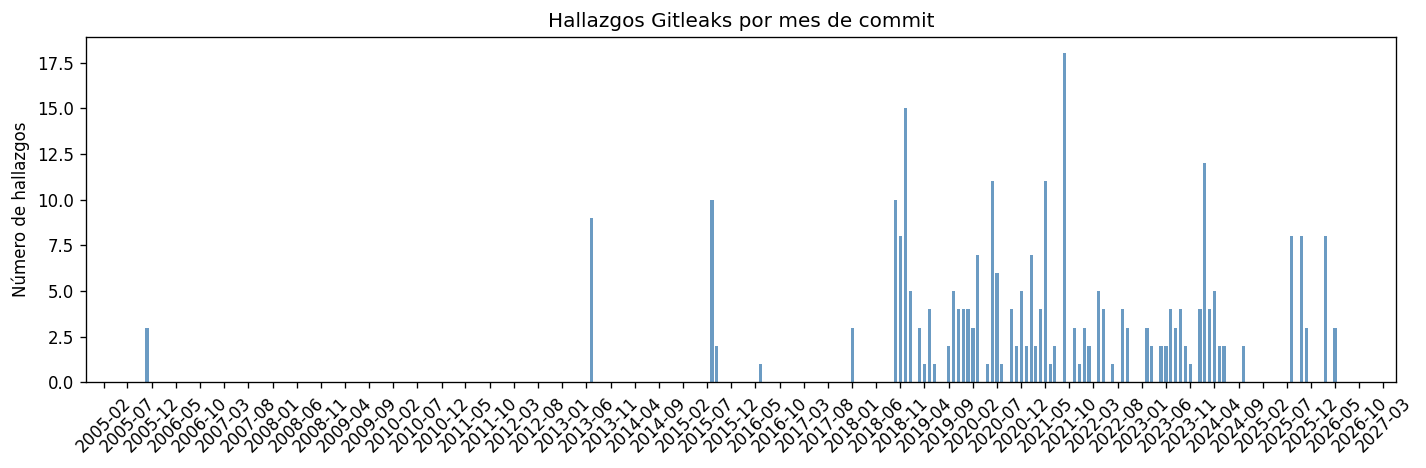

In [7]:
if not df.empty and df['fecha'].notna().any():
    df_t = df.dropna(subset=['fecha']).copy()
    df_t['mes'] = df_t['fecha'].dt.to_period('M')
    serie = df_t.groupby('mes').size()
    serie.index = serie.index.to_timestamp()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(serie.index, serie.values, width=20, color='steelblue', alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=max(1, len(serie) // 12)))
    plt.xticks(rotation=45)
    ax.set_title('Hallazgos Gitleaks por mes de commit')
    ax.set_ylabel('Número de hallazgos')
    plt.tight_layout()
    plt.show()

## 7. Archivos con mayor concentración de secretos

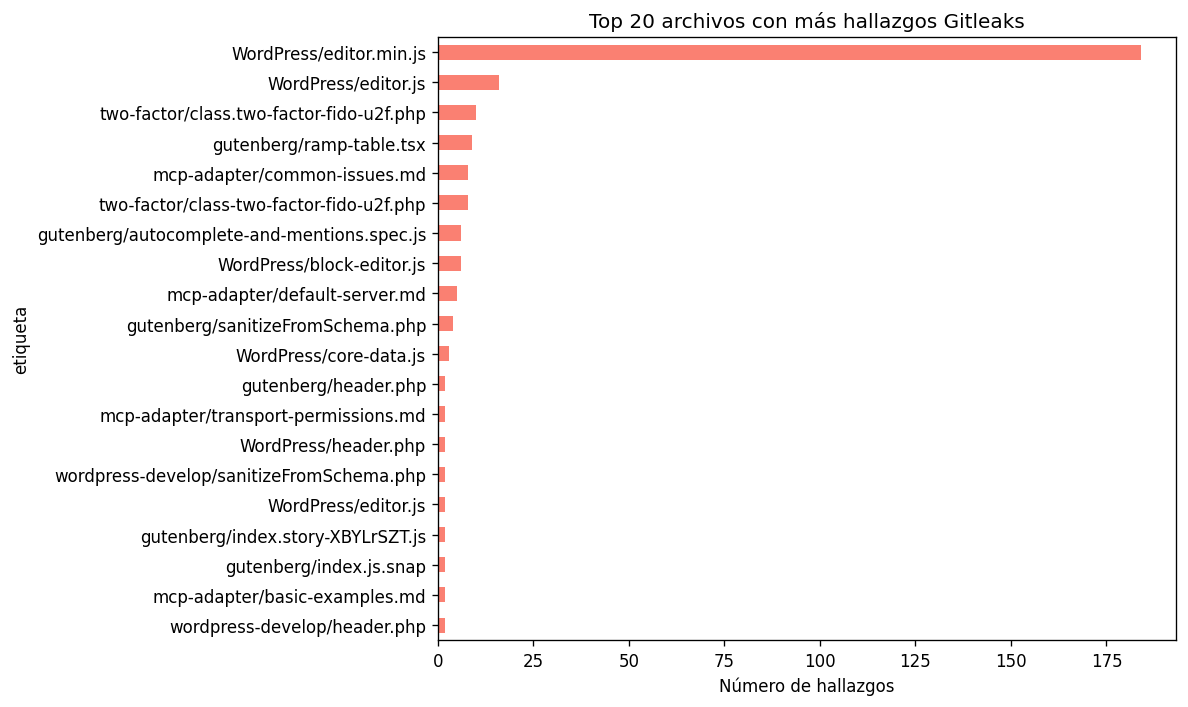

In [8]:
if not df.empty:
    top_archivos = df.groupby(['repositorio', 'archivo']).size().reset_index(name='hallazgos')
    top_archivos = top_archivos.sort_values('hallazgos', ascending=False).head(20)
    top_archivos['etiqueta'] = top_archivos['repositorio'] + '/' + top_archivos['archivo'].apply(
        lambda p: Path(p).name
    )

    top_archivos.set_index('etiqueta')['hallazgos'].sort_values().plot(
        kind='barh', figsize=(10, 6), color='salmon'
    )
    plt.title('Top 20 archivos con más hallazgos Gitleaks')
    plt.xlabel('Número de hallazgos')
    plt.tight_layout()
    plt.show()